In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

print("Images loaded successfully.")

Images loaded successfully.


In [3]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

print("Data concatenated successfully.")

Data concatenated successfully.


In [4]:
All_data_normalized = All_data / 255.0

print("Data normalized successfully.")

Data normalized successfully.


In [5]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

print("Labels encoded and data split successfully.")

Labels encoded and data split successfully.


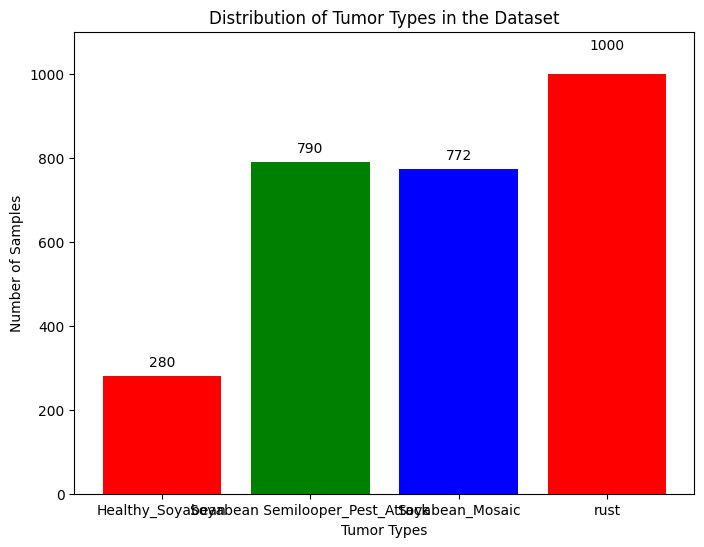

Data distribution plotted successfully.


In [6]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

print("Data distribution plotted successfully.")

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Number of classes
NUM_CLASSES = len(label_encoder.classes_)

# =========================
# Pretrained VGG19
# =========================
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

# =========================
# Build Model
# =========================
inputs = tf.keras.Input(shape=(64, 64, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

# =========================
# Compile Model
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()



I0000 00:00:1784570434.795775      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784570434.799025      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 2, 2, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,026,436 (76.39 MB)

 Trainable params: 2,052 (8.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [8]:
history_finetune = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
 7/72 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2111 - loss: 1.5811

I0000 00:00:1784570443.090641     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.3542 - loss: 1.3089 - val_accuracy: 0.6081 - val_loss: 1.1723
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4756 - loss: 1.1613 - val_accuracy: 0.6714 - val_loss: 1.0631
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5794 - loss: 1.0553 - val_accuracy: 0.6626 - val_loss: 0.9707
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6265 - loss: 0.9667 - val_accuracy: 0.6924 - val_loss: 0.9043
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6582 - loss: 0.9103 - val_accuracy: 0.7188 - val_loss: 0.8542
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6846 - loss: 0.8631 - val_accuracy: 0.7311 - val_loss: 0.8115
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6951 - loss: 0.8353 - val_accuracy: 0.7311 - val_loss: 0.7790
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7162 - loss: 0.8000 - val_accuracy: 0.7575 - val_loss: 0

In [9]:

# =========================
# Evaluate
# =========================
loss, accuracy = model.evaluate(
    test_data,
    test_labels,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8084 - loss: 0.5742
Test Loss: 0.5742
Test Accuracy: 0.8084


In [10]:

# =========================
# Evaluate
# =========================
loss, accuracy = model.evaluate(
    test_data,
    test_labels,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# =========================
# Predictions
# =========================
import numpy as np

y_pred_prob = model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

# =========================
# Average Accuracy
# =========================
from sklearn.metrics import accuracy_score, balanced_accuracy_score

overall_accuracy = accuracy_score(test_labels, y_pred)
balanced_accuracy = balanced_accuracy_score(test_labels, y_pred)

print("Overall Accuracy :", round(overall_accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8084 - loss: 0.5742
Test Loss: 0.5742
Test Accuracy: 0.8084
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step
Overall Accuracy : 0.8084
Balanced Accuracy: 0.7847


In [11]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict probabilities
y_pred_prob = model.predict(test_data)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = test_labels

# Accuracy
acc = accuracy_score(y_true, y_pred)

# Average (balanced) accuracy
avg_acc = balanced_accuracy_score(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Average Accuracy (Balanced Accuracy): {avg_acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Accuracy: 0.8084
Average Accuracy (Balanced Accuracy): 0.7847

Classification Report:
                                 precision    recall  f1-score   support

               Healthy_Soyabean       0.95      0.67      0.79        55
Soyabean Semilooper_Pest_Attack       0.92      0.92      0.92       157
                Soyabean_Mosaic       0.71      0.72      0.71       156
                           rust       0.78      0.83      0.80       201

                       accuracy                           0.81       569
                      macro avg       0.84      0.78      0.81       569
                   weighted avg       0.81      0.81      0.81       569



18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


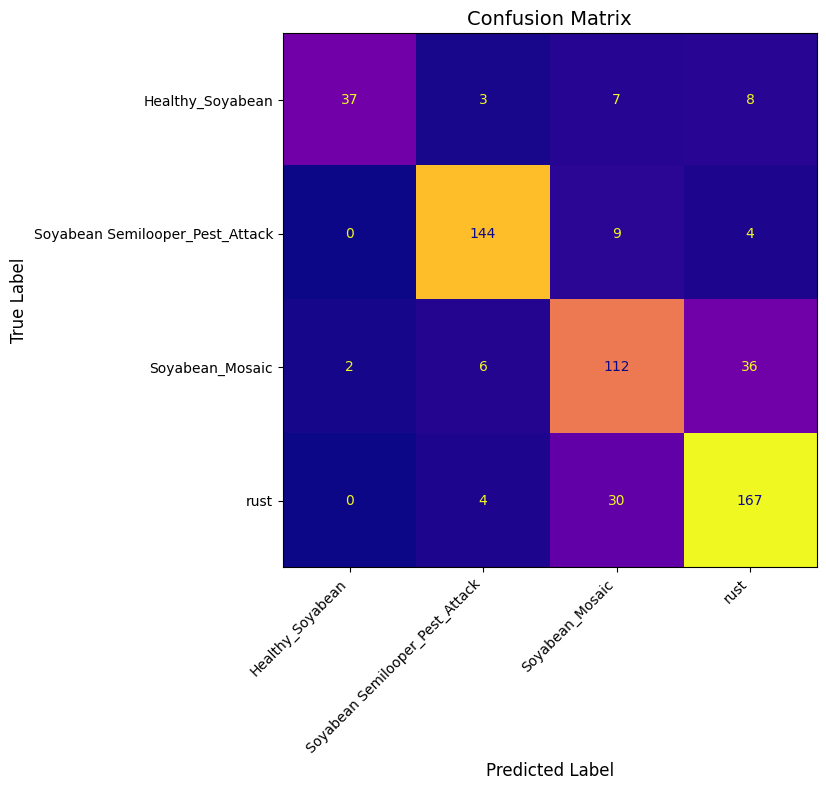

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_prob = model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)

# Larger figure
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    cmap="plasma",
    values_format="d",
    colorbar=False
)

# Fix overlapping labels
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

# Adjust layout automatically
plt.tight_layout()

plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


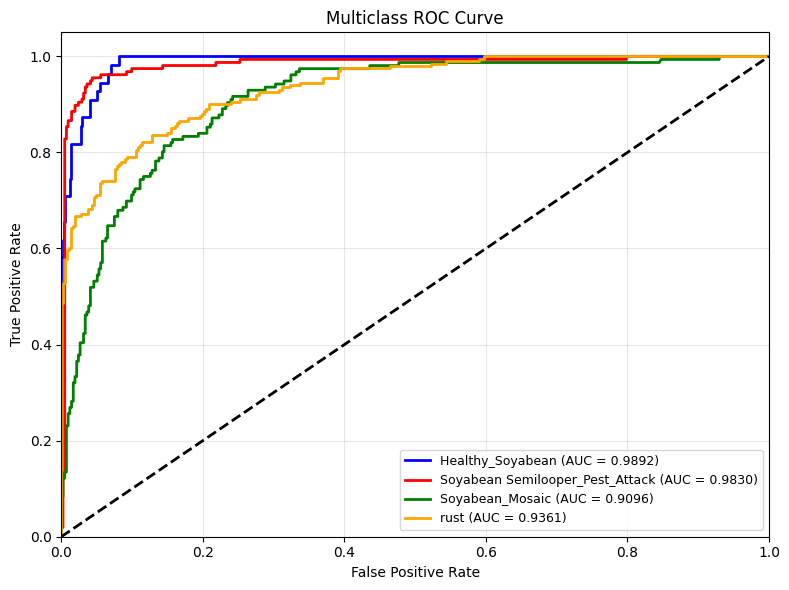

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Predict probabilities
y_score = model.predict(test_data)

# Number of classes
n_classes = len(label_encoder.classes_)

# Convert labels to one-hot format
y_test_bin = label_binarize(test_labels, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8,6))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.4f})'
    )

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right', fontsize=9)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()